In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [31]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [33]:
missing = df.isnull().sum()
missing[missing > 0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [36]:
df.shape

(48895, 16)

<Axes: xlabel='room_type', ylabel='count'>

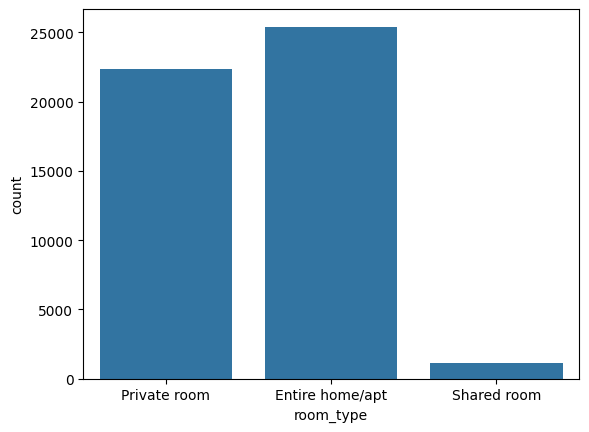

In [37]:
df['room_type'].value_counts()  #Class imbalance and this will give biasness


sns.countplot(x = 'room_type', data=df)

Univariate Analysis - Numeric Features

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

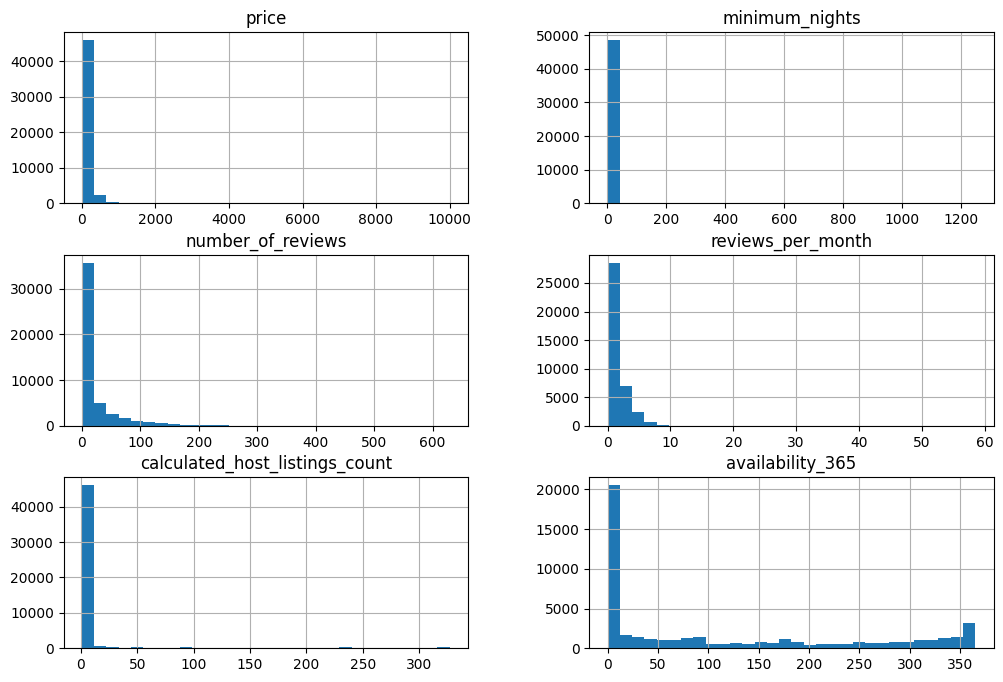

In [38]:
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
df[numeric_cols].hist(bins=30, figsize=(12,8))

Univariate Analysis - Categorical Features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

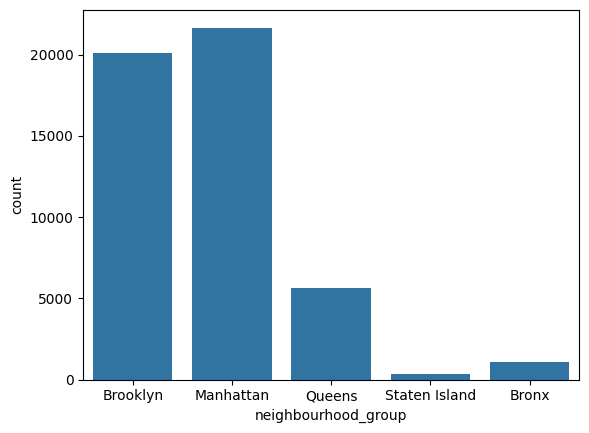

In [39]:
sns.countplot(data=df, x='neighbourhood_group')

Bivariate Analysis - Features vs Target


<Axes: xlabel='room_type', ylabel='price'>

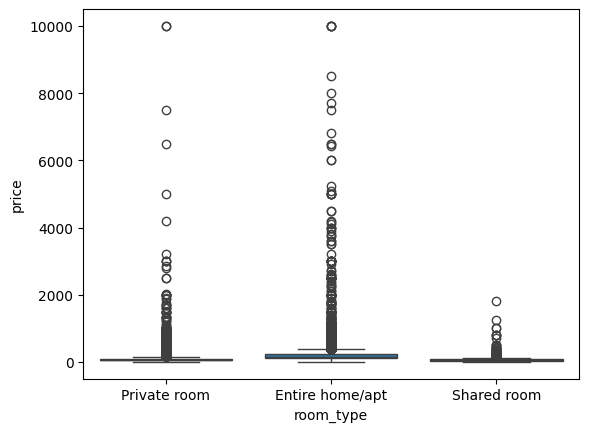

In [40]:
sns.boxplot(x='room_type', y='price', data=df)

### Outlier Detection for Other Numerical Features

Let's visualize the distribution of other numerical columns using box plots to identify potential outliers.

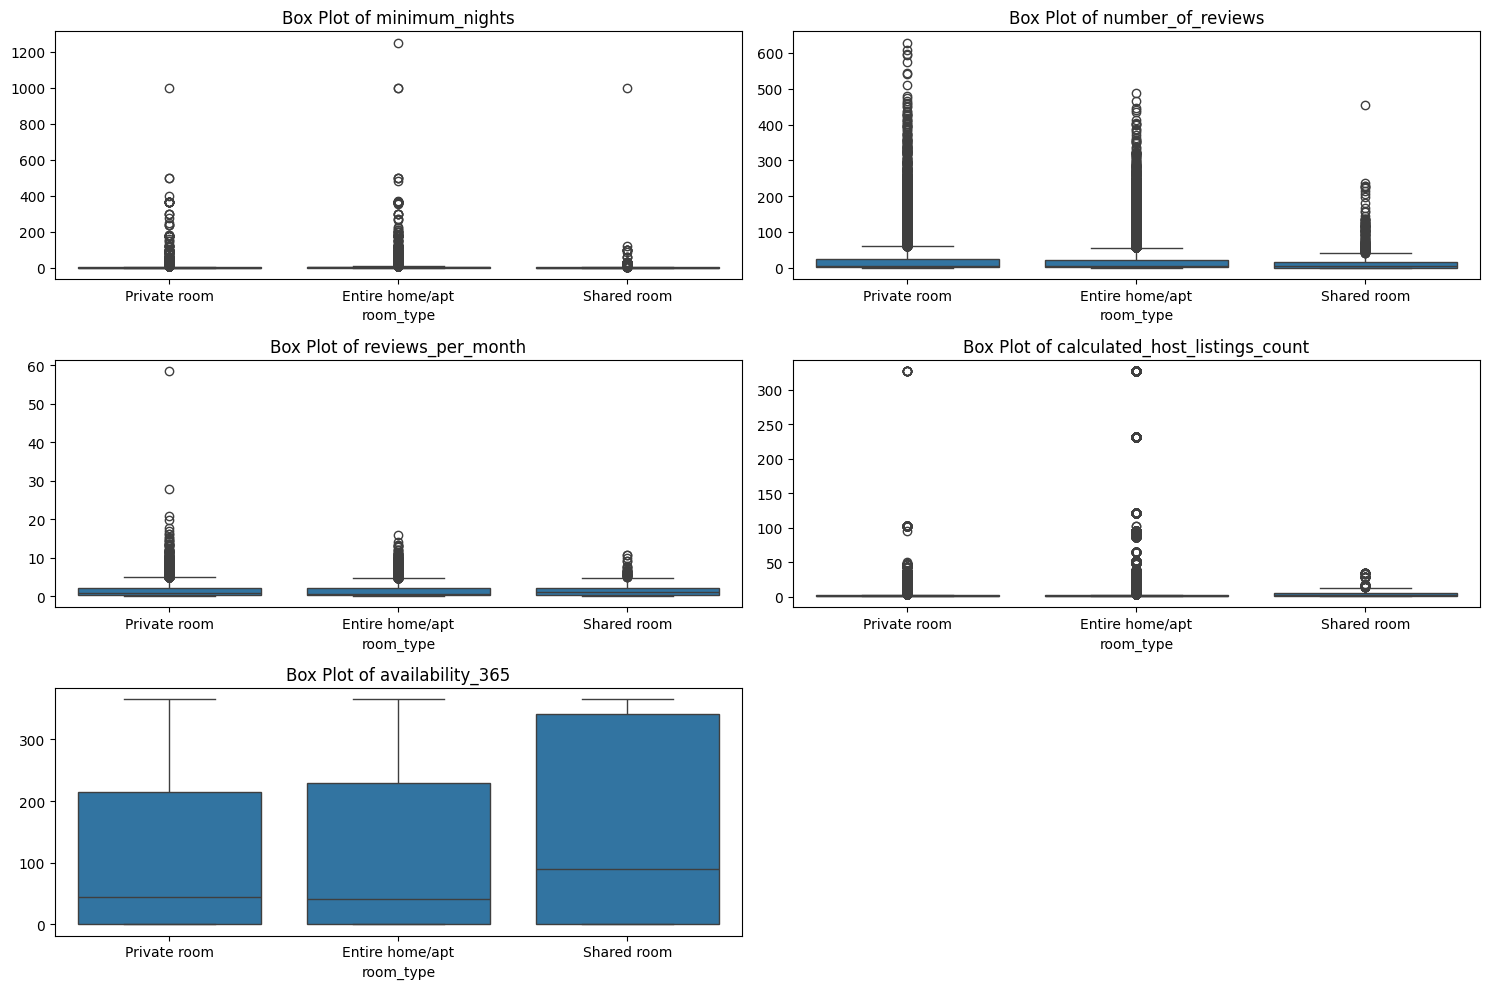

In [41]:
numerical_cols_to_check = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_to_check):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(y=df[col], x=df['room_type'])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Correlation Between Numeric Features

<Axes: >

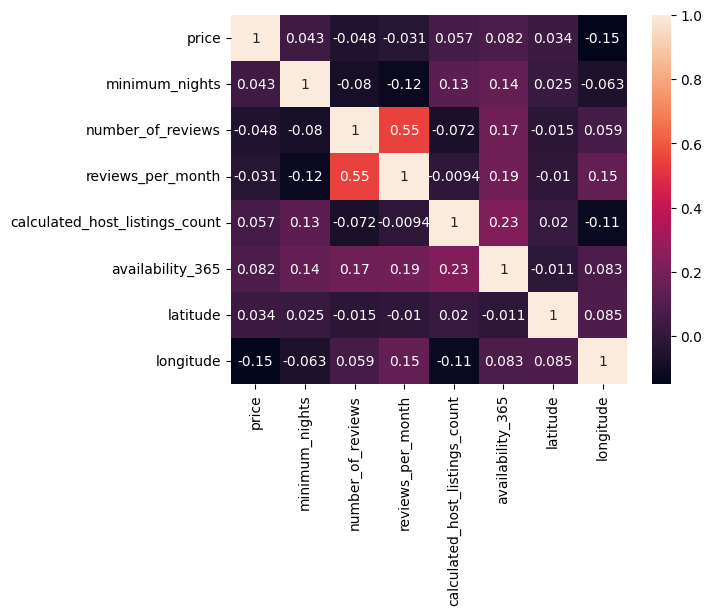

In [42]:
corr = df[numeric_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr, annot=True)

Geographic Distribution (Bonus Visual)

<Axes: xlabel='longitude', ylabel='latitude'>

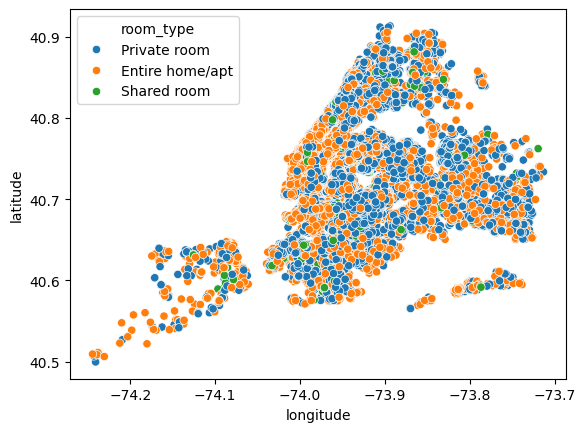

In [43]:
sns.scatterplot(x='longitude', y='latitude', data=df, hue='room_type')

In [45]:
df_clean = df.drop(columns=['id','name','host_id','last_review', 'host_name'])
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [46]:
price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)
reviews_cap = df_clean['number_of_reviews'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper = price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper = nights_cap)
df_clean['number_of_reviews'] = df_clean['number_of_reviews'].clip(upper = reviews_cap)

In [47]:
x=df_clean.drop(columns=['room_type'])
y=df_clean['room_type']


In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42, stratify=y)
#stratify ensures that the same proportion of data goes in both the test and the train. that means it helps reducing the class imbalancing

In [49]:
df_clean[numeric_cols].skew()

,0
price,2.776321
minimum_nights,2.360347
number_of_reviews,2.752794
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408


In [50]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [51]:
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']
categorical_cols = ['neighbourhood_group', 'neighbourhood']

In [52]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('transformer', PowerTransformer()),
    ('scaler', StandardScaler())
])


categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

In [53]:
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('transformer',
                                                  PowerTransformer()),
                                                 ('scaler', StandardScaler())]),
                                 ['price', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365', 'latitude',
                                  'longitude']),
                                ('categorical',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

Smote for class Imabalance
===========================
High chances of overfitting
Data Leakage

In [54]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import QuantileTransformer

# Modify the numeric pipeline to use QuantileTransformer instead of PowerTransformer
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('transformer', QuantileTransformer(output_distribution='normal')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear'),
    'Decision Tree' : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest' : RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42)
}


for name, model in models.items():
  pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('model', model)
  ])
  accuracy = cross_val_score(pipe, x_train, y_train, cv=3, scoring='accuracy')
  f1_macro = cross_val_score(pipe, x_train, y_train, cv=3, scoring='f1_macro')

  print(f'{name} Accuracy: {accuracy.mean()}')
  print(f'{name} F1 Macro: {f1_macro.mean()}')


Logistic Regression Accuracy: 0.8193166888468656
Logistic Regression F1 Macro: 0.5880581777614903
Decision Tree Accuracy: 0.7830214379142854
Decision Tree F1 Macro: 0.6514684652999273
Random Forest Accuracy: 0.8485301494711698
Random Forest F1 Macro: 0.7151644953602978
Gradient Boosting Accuracy: 0.8500564569091907
Gradient Boosting F1 Macro: 0.7068832449707743


In [61]:
from sklearn.model_selection import RandomizedSearchCV
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42)),
])

param_distribution = {
    'classifier__n_estimators': [100, 200, 150,300],
    'classifier__max_depth': [8, 12, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    )
search.fit(x_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('transformer',
                                                                                                QuantileTransformer(output_distribution='normal')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_l...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [62]:
print("Best CV Macro-F1", search.best_score_)

Best CV Macro-F1 0.7297110056398246


In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(x_test)
print(f"Accurace: {accuracy_score(y_test, y_pred)}")
print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro')}")

Accurace: 0.8556643529995042
F1 Macro: 0.737522562261124


<Axes: >

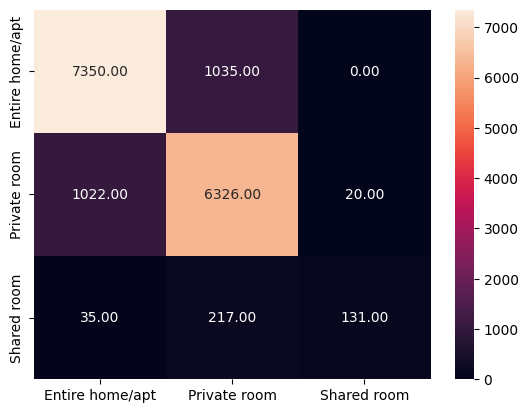

In [65]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.2f', xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)
#

In [66]:
import joblib

joblib.dump(best_pipeline, "Model_Pipeline.pkl")

['Model_Pipeline.pkl']